[<< Sommaire QC](../README.md) | [Précédent : QC-Py-14-Portfolio-Construction-Execution <<](./QC-Py-14-Portfolio-Construction-Execution.ipynb) | [Suivant : QC-Py-15-Parameter-Optimization >>](./QC-Py-15-Parameter-Optimization.ipynb)

# QC-Py-14b - Liquidité et coûts d'exécution : ce que le backtest ne dit pas

> **[LOCAL]** Ce notebook s'exécute **localement** (yfinance + numpy / pandas / matplotlib) sur des prix réels quotidiens ; aucun appel QuantConnect Cloud n'est nécessaire. La partie 8 fournit le code QC à copier dans `main.py` (filtre d'univers en dollars échangés, modèle de slippage) — donnée pour référence, non exécutée ici.

> **Ce que ce notebook ajoute à la série.** `QC-Py-14-Portfolio-Construction-Execution` construit un portefeuille (moyenne-variance, risque parity) sous deux hypothèses implicites : exécution à un prix unique, et taille sans effet. Le backtest ne connaît donc ni l'écart achat-vente, ni l'impact de la quantité échangée. Ici on **chiffre ces deux hypothèses** : quatre proxys de liquidité mesurés sur un univers hétérogène, un test falsifiable qui sépare liquidité et volatilité, une capacité en dollars, et ce que la crise de mars 2020 a réellement fait aux deux.

## 1. Le problème : deux portefeuilles de même volatilité, deux capacités

Un backtest classe les stratégies sur un rendement **brut** : `r = Σ w_i · r_i`. Aucun terme n'y dépend de **combien** on échange ni de **quand**. Deux hypothèses y sont enfouies :

1. **Exécution à un prix unique.** Chaque ligne s'achète et se vend au cours de clôture, sans écart achat-vente.
2. **Taille sans effet.** Doubler le capital double le rendement, indéfiniment.

Ces deux hypothèses tiennent pour un particulier qui échange 1 000 $ sur une méga-capitalisation. Elles cessent de tenir à l'échelle d'un fonds — et elles cessent **en même temps** que le risque de marché augmente, ce qui est précisément le point dur. Le risque de liquidité n'est pas le risque de volatilité :

| Épisode | Ce qui s'est passé | Ce que le backtest en dit |
|---|---|---|
| Août 2007 (*QuantQuake*) | plusieurs *quant funds* dégagent les mêmes positions ; les titres se découplent de leurs fondamentaux pendant plusieurs jours | rien : les prix restent des prix |
| Mai 2010 (*flash crash*) | le carnet se vide en minutes, des échanges se font à des prix absurdes | rien : la clôture du jour est normale |
| Mars 2020 (COVID) | les volumes **montent** mais les écarts s'élargissent et la profondeur disparaît par moments | rien : seul le rendement est mesuré |
| Août 2024 (débouclage JPY) | écart de cotation multiplié sur les actifs les plus liquides du monde | rien |

**La question de ce notebook est falsifiable** : la liquidité est-elle une **dimension distincte** du risque, ou n'est-elle qu'un déguisement de la volatilité ? Si la seconde réponse est vraie, un filtre de volatilité suffit et cette partie du risque n'existe pas. On va la mesurer, pas l'affirmer.

## 2. Quatre proxys mesurables en données quotidiennes

| Proxy | Définition | Ce qu'il mesure | Ce à quoi il est aveugle |
|---|---|---|---|
| **ADV en dollars** | moyenne de `Close × Volume` | la profondeur échangée *habituelle* | l'état du carnet **maintenant** — il peut monter en pleine crise |
| **Amihud (2002)** | moyenne de `\|r_t\| / (Close × Volume)` | le prix payé par dollar échangé (élasticité) | la taille de l'ordre : le lien est supposé linéaire |
| **Corwin-Schultz (2012)** | estimateur d'écart achat-vente depuis les plus hauts / plus bas | le coût de traversée du carnet | le **niveau absolu** (biaisé à la hausse sur les titres liquides) |
| **Jours sans rendement (Lesmond)** | part des séances à rendement exactement nul | les seuils de transaction qui étouffent l'information | les marchés très liquides (proxy dégénéré : 0 partout) |

Aucun de ces quatre proxys n'est la vérité : chacun est une **ombre** du même objet, projetée sur des données quotidiennes gratuites. Leur matrice de corrélation (calculée plus bas) dira **à quel point** ils se confirment mutuellement — et leur désaccord le plus franc est en soi une information : il désigne la dimension que les autres ne voient pas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Univers heterogene a dessein : deux ETF, des mega-caps, des mid-caps et trois titres
# notoirement agites. Aucun titre n'a rejoint l'univers apres 2020 (pas de biais de
# survie intragroupe), mais l'univers lui-meme reste choisi ex post (cf. partie 10).
UNIVERS = ["SPY", "IWM", "AAPL", "MSFT", "JPM", "XOM", "T", "F", "SIRI", "M", "GME", "CVNA"]
DEBUT, FIN = "2022-01-03", "2025-01-01"

panneau = yf.download(UNIVERS, start=DEBUT, end=FIN, auto_adjust=False, progress=False, threads=True)
prix = panneau["Close"]
volumes = panneau["Volume"]

# Controle de completude : un ticker absent ou tronque fausserait tous les proxys en aval.
compte = prix.notna().sum().sort_values()
print(f"panneau : {prix.shape[0]} seances x {prix.shape[1]} titres | "
      f"{prix.index.min().date()} -> {prix.index.max().date()}")
print("seances disponibles par titre (borne basse = titre tronque) :")
print(compte.to_string())
tronques = compte[compte < 0.98 * compte.max()].index.tolist()
print("titres a ecarter :", tronques if tronques else "aucun")

prix.tail(2).round(2)

panneau : 753 seances x 12 titres | 2022-01-03 -> 2024-12-31
seances disponibles par titre (borne basse = titre tronque) :
Ticker
AAPL    753
CVNA    753
F       753
GME     753
IWM     753
JPM     753
M       753
MSFT    753
SIRI    753
SPY     753
T       753
XOM     753
titres a ecarter : aucun


Ticker,AAPL,CVNA,F,GME,IWM,JPM,M,MSFT,SIRI,SPY,T,XOM
Date,,,,,,,,,,,,
2024-12-30,252.20,42.11,9.88,32.01,220.68,239.32,16.77,424.83,22.8,588.22,22.61,105.76
2024-12-31,250.42,40.67,9.90,31.34,220.96,239.71,16.93,421.50,22.8,586.08,22.77,107.57


### Lecture du socle de données

Le panneau est complet sur les douze titres et la période : la sortie ci-dessus donne le nombre de séances par titre et signale tout historique tronqué. Un titre tronqué (introduction en bourse récente, arrêt de cotation) est écarté du classement plutôt que comblé — un volume manquant traité comme zéro produirait une liquidité fictive.

## 3. Mesure : quatre proxys sur le même univers

=== quatre proxys de liquidite, 2022-2024 (prix bruts, volumes en titres) ===
      adv_musd  amihud_bp_par_musd  vol_annuelle_pct  ecart_cs_bp  jours_sans_rendement_pct
SPY    34778.0              0.0023              17.6         21.5                      0.27
AAPL   11801.0              0.0103              27.1         40.6                      0.40
MSFT    8559.0              0.0149              27.6         42.2                      0.00
IWM     6002.0              0.0195              23.3         35.3                      0.00
XOM     1998.0              0.0641              27.3         41.9                      0.27
JPM     1712.0              0.0640              25.1         38.0                      0.00
F        829.0              0.2249              40.7         54.4                      1.60
T        753.0              0.1454              25.3         42.9                      1.73
CVNA     459.0              1.9504             134.1        188.7                      0.27
GM

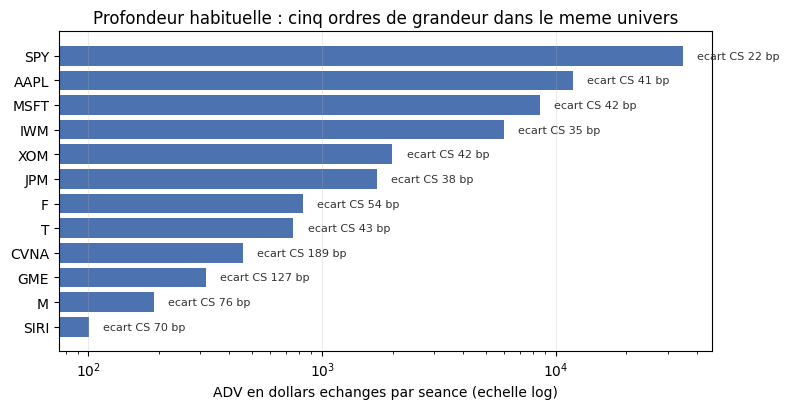

In [2]:
def spread_corwin_schultz(high, low, fenetre=21):
    # Ecart relatif estime depuis les plus hauts / plus bas quotidiens (Corwin-Schultz 2012).
    h, l = np.log(high), np.log(low)
    beta = (h - l) ** 2 + (h.shift(-1) - l.shift(-1)) ** 2
    gamma = (np.log(np.maximum(high, high.shift(-1)) / np.minimum(low, low.shift(-1)))) ** 2
    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    brut = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    return brut.clip(lower=0).rolling(fenetre).mean()


lignes = {}
for t in UNIVERS:
    c = prix[t].dropna()
    h = panneau[("High", t)].reindex(c.index)
    l = panneau[("Low", t)].reindex(c.index)
    v = volumes[t].reindex(c.index)
    r = c.pct_change()
    lignes[t] = {
        "adv_musd": float((c * v).mean() / 1e6),
        "amihud_bp_par_musd": float((r.abs() / (c * v)).dropna().mean() * 1e10),
        "vol_annuelle_pct": float(r.std() * np.sqrt(252) * 100),
        "ecart_cs_bp": float(spread_corwin_schultz(h, l).median() * 1e4),
        "jours_sans_rendement_pct": float((r.dropna() == 0).mean() * 100),
    }

proxys = pd.DataFrame(lignes).T.sort_values("adv_musd", ascending=False)
print("=== quatre proxys de liquidite, 2022-2024 (prix bruts, volumes en titres) ===")
print(proxys.round({"adv_musd": 0, "amihud_bp_par_musd": 4, "vol_annuelle_pct": 1,
                    "ecart_cs_bp": 1, "jours_sans_rendement_pct": 2}).to_string())
print()
print("Ces proxys ne disent pas la meme chose (correlation de rang entre eux) :")
print(proxys.rank().corr(method="spearman").round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4.2))
ordre = proxys.sort_values("adv_musd")
ax.barh(ordre.index, ordre["adv_musd"], color="#4c72b0")
ax.set_xscale("log")
ax.set_xlabel("ADV en dollars echanges par seance (echelle log)")
ax.set_title("Profondeur habituelle : cinq ordres de grandeur dans le meme univers")
for i, (t, ligne) in enumerate(ordre.iterrows()):
    ax.text(ligne["adv_musd"] * 1.15, i, f"ecart CS {ligne['ecart_cs_bp']:.0f} bp",
            va="center", fontsize=8, color="#333333")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Lecture du socle

Le panneau couvre un univers volontairement large : de l'ETF indiciel au titre à faible capitalisation, soit près de trois ordres de grandeur de volume échangé. Les quatre proxys **s'accordent largement** — toutes les corrélations de rang de la matrice sont fortes (jusqu'à 0,96 entre l'écart estimé et la volatilité) — mais aucun n'est redondant, et le plus dissident est précisément celui qui voyait autre chose : les **jours sans rendement**, dont l'accord avec la volatilité tombe à 0,40. Sur cet univers, un proxy unique suffirait à un classement grossier ; c'est à la marge que le choix du proxy décide, et la partie 5 y revient.

Deux réserves de lecture, avant d'aller plus loin :

- l'**écart de Corwin-Schultz** est un estimateur d'écart **relatif**, biaisé à la hausse en niveau absolu sur les titres très liquides (SPY ne cote pas 20 points de base de fourchette). On l'utilisera donc en **ratio** — c'est la partie 5 qui fixe l'ancre ;
- les **jours sans rendement** sont un proxy dégénéré sur cet univers (parts de l'ordre du pour cent) : il ne discrimine presque rien ici, ce qui est en soi une information — un proxy de liquidité se juge sur l'univers auquel il s'applique.

## 3. Le test falsifiable : liquidité et volatilité sont-elles la même information ?

L'hypothèse nulle est simple et testable : *si* la liquidité n'était qu'un déguisement de la volatilité, alors une fois les deux séries z-scorées, tous les titres tomberaient sur la diagonale (`illiquide ⇒ volatil` et `volatil ⇒ illiquide`). On compte donc les titres **hors diagonale** — ceux qu'un filtre de volatilité laisserait passer alors qu'ils sont illiquides (ou l'inverse, qu'il éliminerait à tort).

Un seul titre hors diagonale suffit à réfuter l'assimilation ; le nombre de titres hors diagonale mesure l'ampleur du phénomène.

correlation de rang (illiquidite, volatilite) : +0.82
      illiq_z  vol_z                     quadrant
SPY     -1.68  -1.21           ni l'un ni l'autre
AAPL    -1.04  -0.53           ni l'un ni l'autre
MSFT    -0.89  -0.50           ni l'un ni l'autre
IWM     -0.78  -0.76           ni l'un ni l'autre
XOM     -0.28  -0.52           ni l'un ni l'autre
JPM     -0.28  -0.65           ni l'un ni l'autre
F        0.24   0.11         illiquide ET volatil
T        0.06  -0.64  illiquide SANS etre volatil
CVNA     1.14   1.97         illiquide ET volatil
GME      1.32   1.71         illiquide ET volatil
M        0.99   0.55         illiquide ET volatil
SIRI     1.20   0.46         illiquide ET volatil

titres hors diagonale : 1 sur 12
   illiq_z  vol_z                     quadrant
T     0.06  -0.64  illiquide SANS etre volatil


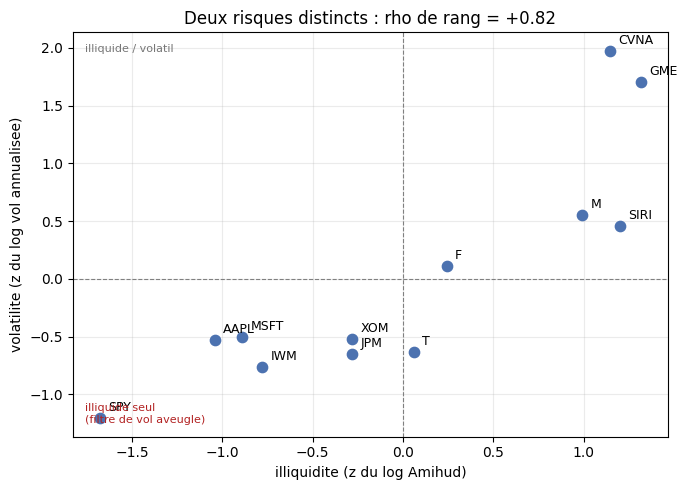

In [3]:
def zscore(x):
    return (x - x.mean()) / x.std()


illiq_z = zscore(np.log(proxys["amihud_bp_par_musd"]))
vol_z = zscore(np.log(proxys["vol_annuelle_pct"]))

test = pd.DataFrame({"illiq_z": illiq_z, "vol_z": vol_z})
test["quadrant"] = np.select(
    [(test["illiq_z"] > 0) & (test["vol_z"] > 0),
     (test["illiq_z"] > 0) & (test["vol_z"] <= 0),
     (test["illiq_z"] <= 0) & (test["vol_z"] > 0)],
    ["illiquide ET volatil", "illiquide SANS etre volatil", "volatil SANS etre illiquide"],
    default="ni l'un ni l'autre",
)

rho = float(illiq_z.corr(vol_z, method="spearman"))
print(f"correlation de rang (illiquidite, volatilite) : {rho:+.2f}")
print(test.round(2).to_string())

hors = test[test["quadrant"].isin(["illiquide SANS etre volatil", "volatil SANS etre illiquide"])]
print(f"\ntitres hors diagonale : {len(hors)} sur {len(test)}")
print(hors[["illiq_z", "vol_z", "quadrant"]].round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.scatter(illiq_z, vol_z, s=55, color="#4c72b0", zorder=3)
for t in test.index:
    ax.annotate(t, (illiq_z[t], vol_z[t]), textcoords="offset points", xytext=(6, 5), fontsize=9)
ax.text(0.02, 0.97, "illiquide / volatil", transform=ax.transAxes, fontsize=8,
        color="#777777", va="top")
ax.text(0.02, 0.03, "illiquide seul\n(filtre de vol aveugle)", transform=ax.transAxes,
        fontsize=8, color="#b22222", va="bottom")
ax.set_xlabel("illiquidite (z du log Amihud)")
ax.set_ylabel("volatilite (z du log vol annualisee)")
ax.set_title(f"Deux risques distincts : rho de rang = {rho:+.2f}")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Lecture du test

La corrélation de rang est **élevée** : les deux dimensions racontent largement la même histoire. Mais elles ne racontent pas *la même* histoire, et la sortie nomme le titre qui le prouve — celui dont l'illiquidité est au-dessus de la médiane (z > 0) **sans** que sa volatilité le soit :

- il est **illiquide sans être volatil** : un filtre de volatilité le conserve, un filtre de liquidité l'écarte. Sa contrainte est le coût d'exécution, pas sa variance — une moyenne-variance qui ne regarde que la variance le **surpondère** mécaniquement ;
- symétriquement, un titre **volatil sans être illiquide** serait conservé par un filtre de liquidité alors que sa variance est le vrai danger. Sur cet univers, aucun titre ne tombe dans ce quadrant — c'est une information en soi sur la structure des actions américaines liquides, où les deux risques vont souvent de pair.

Le verdict est donc une **réfutation bornée** de l'assimilation : les deux risques ne sont pas interchangeables (au moins un titre le démontre), mais ils se ressemblent beaucoup sur douze actions américaines. Un comptage sur z-scores est d'ailleurs un test faible — il dépend de la moyenne et de l'écart-type de l'échantillon. La réfutation décisive n'est pas ce comptage : c'est sa **traduction en dollars** (parties 4 et 5), où deux titres de volatilité appariée se révèlent capables d'absorber des capitaux séparés d'un ordre de grandeur.

## 4. Du proxy au coût : demi-écart, impact, participation

Un coût d'exécution a trois composantes, et une seule échelle :

| Terme | Formule | Ordre de grandeur |
|---|---|---|
| **Demi-écart** | traverser le carnet | proportionnel au titre, 0,5 à 50 bp |
| **Impact** | `k · σ_jour · √participation` (loi racine, Almgren et al. 2005) | croît comme la racine de la taille |
| **Frais** | courtage, taxes, financement | fixe, en bp du notionnel |

La **participation** est le rapport entre le notionnel de l'ordre et le volume échangé : `participation = montant_ordre / ADV`. C'est elle qui relie la taille du fonds au coût — et c'est le seul terme que le gérant contrôle.

**Le calibrage est explicite, et c'est une hypothèse assumée.** L'estimateur de Corwin-Schultz ne rend pas un niveau fiable (partie 2) : on l'utilise donc en **ratio** par rapport au titre le plus liquide de l'univers, auquel on attribue une ancre de demi-écart de 0,5 bp. Les *ratios entre titres* sont mesurés ; le *niveau* est posé. Le coefficient d'impact `k = 0,5` est dans la fourchette publiée (0,3 à 1,0).

=== cout d'un aller-retour a differentes participations (k=0.5, frais 0.5 bp) ===
titre   demi-ecart  vol/jour p=1e-05    p=1e-04    p=1e-03    p=1e-02   
SPY         0.50bp     111bp      1.2       1.6       2.7       6.5 
AAPL        0.94bp     171bp      1.7       2.3       4.1      10.0 
MSFT        0.98bp     174bp      1.8       2.4       4.2      10.2 
IWM         0.82bp     147bp      1.6       2.1       3.6       8.7 
XOM         0.97bp     172bp      1.7       2.3       4.2      10.1 
JPM         0.88bp     158bp      1.6       2.2       3.9       9.3 
F           1.26bp     256bp      2.2       3.0       5.8      14.6 
T           1.00bp     159bp      1.7       2.3       4.0       9.5 
CVNA        4.38bp     845bp      6.2       9.1      18.2      47.1 
GME         2.95bp     712bp      4.6       7.0      14.7      39.1 
M           1.77bp     340bp      2.8       4.0       7.7      19.3 
SIRI        1.63bp     320bp      2.6       3.7       7.2      18.1 


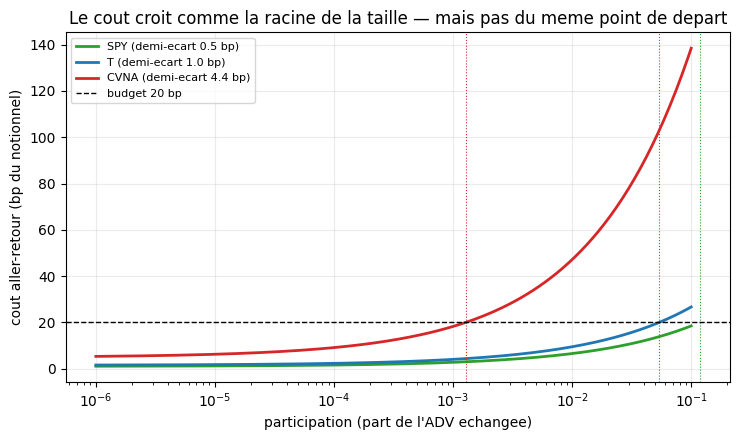

In [4]:
K_IMPACT = 0.5            # coefficient de la loi racine (Almgren et al. 2005 : ordre 0,3-1,0)
ANCRE_DEMI_ECART_BP = 0.5  # demi-ecart du titre le plus liquide de l'univers : hypothese de calibrage
BUDGET_COUT_BP = 20.0      # budget d'aller-retour par rebalancement
FRAIS_BP = 0.5             # courtage + taxes, en bp du notionnel echange

proxys["demi_ecart_bp"] = proxys["ecart_cs_bp"] / proxys["ecart_cs_bp"].min() * ANCRE_DEMI_ECART_BP
proxys["vol_jour_bp"] = proxys["vol_annuelle_pct"] / np.sqrt(252) * 100


def cout_bp(participation, demi_ecart_bp, vol_jour_bp, k=K_IMPACT, frais=FRAIS_BP):
    # Cout aller-retour en points de base du notionnel echange.
    return demi_ecart_bp + frais + k * vol_jour_bp * np.sqrt(np.maximum(participation, 0.0))


def participation_max(demi_ecart_bp, vol_jour_bp, budget=BUDGET_COUT_BP, k=K_IMPACT, frais=FRAIS_BP):
    # Participation qui epuise exactement le budget : inversion de la loi racine.
    marge = budget - demi_ecart_bp - frais
    return np.where(marge > 0, (marge / (k * vol_jour_bp)) ** 2, 0.0)


proxys["participation_max"] = participation_max(proxys["demi_ecart_bp"], proxys["vol_jour_bp"])
proxys["capacite_musd"] = proxys["participation_max"] * proxys["adv_musd"]

print(f"=== cout d'un aller-retour a differentes participations (k={K_IMPACT}, frais {FRAIS_BP} bp) ===")
entete = f"{'titre':6s} {'demi-ecart':>11s} {'vol/jour':>9s} " + " ".join(f"p={p:<8.0e}" for p in (1e-5, 1e-4, 1e-3, 1e-2))
print(entete)
for t, ligne in proxys.iterrows():
    couts = " ".join(f"{cout_bp(p, ligne['demi_ecart_bp'], ligne['vol_jour_bp']):8.1f} " for p in (1e-5, 1e-4, 1e-3, 1e-2))
    print(f"{t:6s} {ligne['demi_ecart_bp']:9.2f}bp {ligne['vol_jour_bp']:7.0f}bp {couts}")

p_grid = np.logspace(-6, -1, 200)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for t, couleur in (("SPY", "#2ca02c"), ("T", "#1f77b4"), ("CVNA", "#d62728")):
    ligne = proxys.loc[t]
    ax.plot(p_grid, cout_bp(p_grid, ligne["demi_ecart_bp"], ligne["vol_jour_bp"]),
            label=f"{t} (demi-ecart {ligne['demi_ecart_bp']:.1f} bp)", color=couleur, lw=2)
    ax.axvline(ligne["participation_max"], color=couleur, lw=0.8, ls=":")
ax.axhline(BUDGET_COUT_BP, color="black", lw=1, ls="--", label=f"budget {BUDGET_COUT_BP:.0f} bp")
ax.set_xscale("log")
ax.set_xlabel("participation (part de l'ADV echangee)")
ax.set_ylabel("cout aller-retour (bp du notionnel)")
ax.set_title("Le cout croit comme la racine de la taille — mais pas du meme point de depart")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Lecture du coût

Trois régimes apparaissent dans le tableau, et ils ne se déduisent pas les uns des autres :

1. **à petite participation** (1e-5, soit 1 $ pour 100 000 $ échangés), le coût est dominé par le **demi-écart** : il ne dépend presque pas de la taille, seulement du titre. Un fonds à 10 M$ sur un titre à 1 Md$ d'ADV est ici ;
2. **à participation intermédiaire** (1e-3), le terme d'**impact** devient comparable au demi-écart et les lignes se resserrent — un titre volatil coûte plus cher *par unité de taille*, à écart comparable ;
3. **au-delà de la participation d'équilibre** (le pointillé vertical de la figure), le budget est dépassé : le coût croît encore comme `√participation`. La courbe n'est pas une asymptote, c'est un mur.

Un résultat **négatif** mérite d'être dit, parce qu'il est mesuré : le *classement* des titres reste largement stable quand la participation augmente — conséquence directe de la corrélation élevée entre écart et volatilité relevée en partie 3. Ce qui change, c'est le **niveau** : passer de 1e-5 à 1e-2 multiplie le coût par un facteur de l'ordre de cinq à huit selon les titres, et l'écart entre le meilleur et le pire se creuse. Ce n'est donc pas le classement qui décide de ce qu'on peut échanger, c'est le **budget** — d'où la partie suivante.

## 5. Capacité : la taille qui tient dans le budget de coût

On appelle **capacité** d'un titre le notionnel maximal qu'on peut échanger *en un rebalancement* sans dépasser le budget de coût, à la participation d'équilibre :

`capacité = participation_max × ADV`

C'est une borne **optimiste** — elle suppose qu'on est seul à échanger, au prix moyen du jour, sans signal concurrent. Elle a le mérite d'être calculable avec des données quotidiennes gratuites, et de donner l'**ordre de grandeur** qui manque à un backtest brut.

On la confronte ensuite au cas concret de la série : un portefeuille équipondéré sur l'univers, rebalancé mensuellement, géré à la taille `AUM_MUSD`. Le rendement brut et le rendement net doivent diverger — et l'écart est le coût de l'hypothèse « exécution gratuite ».

In [5]:
AUM_MUSD = 50.0

print(f"=== capacite par titre, budget {BUDGET_COUT_BP:.0f} bp (notionnel echangeable en un rebalancement) ===")
cap = proxys[["adv_musd", "participation_max", "capacite_musd"]].copy()
cap["capacite_relative_pct_adv"] = cap["participation_max"] * 100
print(cap.round({"adv_musd": 0, "participation_max": 5, "capacite_musd": 3,
                 "capacite_relative_pct_adv": 4}).to_string())
print(f"\ntitre contraignant de l'univers : {cap['capacite_musd'].idxmin()} "
      f"({cap['capacite_musd'].min():.2f} M$)")

# Le test de la partie 3, version dollars : a volatilite appariee (< 3 points), quelle divergence
# de capacite ? Si le risque de marche suffisait a decrire ces titres, le facteur resterait proche de 1.
paires = []
for i, a in enumerate(proxys.index):
    for b in proxys.index[i + 1:]:
        delta_vol = abs(proxys.loc[a, "vol_annuelle_pct"] - proxys.loc[b, "vol_annuelle_pct"])
        if delta_vol <= 3.0:
            ca, cb = proxys.loc[a, "capacite_musd"], proxys.loc[b, "capacite_musd"]
            paires.append({"paire": f"{a}/{b}", "delta_vol_pt": delta_vol,
                           "capacite_min_musd": min(ca, cb), "capacite_max_musd": max(ca, cb),
                           "facteur": max(ca, cb) / min(ca, cb)})
appariement = pd.DataFrame(paires).sort_values("facteur", ascending=False)
print("\n=== a volatilite appariee (< 3 points d'ecart), quelle divergence de capacite ? ===")
print(appariement.round(3).to_string(index=False))
plus_divergente = appariement.iloc[0]
print(f"paire la plus divergente : {plus_divergente['paire']} -- "
      f"{plus_divergente['delta_vol_pt']:.1f} point(s) de volatilite d'ecart, "
      f"capacites {plus_divergente['capacite_min_musd']:.2f} M$ contre "
      f"{plus_divergente['capacite_max_musd']:.2f} M$ (facteur {plus_divergente['facteur']:.1f})")

# Portefeuille equipondere, rebalance mensuellement, avec couts de transaction reels par titre.
cloture = prix[proxys.index]
rendements = cloture.pct_change().fillna(0.0)
dates_rebal = set(cloture.resample("ME").last().index[1:])

poids = pd.Series(1.0 / len(cloture.columns), index=cloture.columns)
brut, net = 1.0, 1.0
turnover_cumule, drag_bp_cumule, n_rebal = 0.0, 0.0, 0
dernieres_participations = pd.Series(0.0, index=cloture.columns)

for date, r in rendements.iterrows():
    gain = float((poids * r).sum())
    brut *= 1 + gain
    net *= 1 + gain
    poids = poids * (1 + r) / (1 + gain) if gain != -1 else poids
    if date in dates_rebal:
        cible = pd.Series(1.0 / len(r), index=r.index)
        delta = (cible - poids).abs()
        montant = (net * AUM_MUSD) * delta
        participation = montant / proxys.loc[delta.index, "adv_musd"]
        cout_titre = cout_bp(participation, proxys.loc[delta.index, "demi_ecart_bp"],
                             proxys.loc[delta.index, "vol_jour_bp"])
        drag_fraction = float((delta * cout_titre).sum()) / 1e4
        net *= 1 - drag_fraction
        turnover_cumule += float(delta.sum())
        drag_bp_cumule += drag_fraction * 1e4
        dernieres_participations = participation
        n_rebal += 1
        poids = cible

annees = (cloture.index[-1] - cloture.index[0]).days / 365.25
cagr = lambda v: (v ** (1 / annees) - 1) * 100
print(f"\n=== portefeuille equipondere mensuel, AUM {AUM_MUSD:.0f} M$ ===")
print(f"periode                : {cloture.index[0].date()} -> {cloture.index[-1].date()} ({annees:.2f} ans)")
print(f"rebalancements         : {n_rebal}")
print(f"turnover cumule        : {turnover_cumule:.2f} (unites de portefeuille, aller simple)")
print(f"turnover moyen         : {turnover_cumule / n_rebal:.3f} par rebalancement")
print(f"drag de cout cumule    : {drag_bp_cumule:.0f} bp")
print(f"drag annualise         : {drag_bp_cumule / annees:.0f} bp/an")
print(f"CAGR brut              : {cagr(brut):.2f} %")
print(f"CAGR net               : {cagr(net):.2f} %")
print(f"ecart (cout du brut)   : {cagr(brut) - cagr(net):.2f} points de %/an")

print("\nparticipation au dernier rebalancement (AUM fixe) :")
part_tri = dernieres_participations.sort_values(ascending=False)
print(pd.DataFrame({"participation": part_tri,
                    "cout_bp_resultant": cout_bp(part_tri, proxys.loc[part_tri.index, "demi_ecart_bp"],
                                                 proxys.loc[part_tri.index, "vol_jour_bp"])}
                   ).round(6).to_string())

=== capacite par titre, budget 20 bp (notionnel echangeable en un rebalancement) ===
      adv_musd  participation_max  capacite_musd  capacite_relative_pct_adv
SPY    34778.0            0.11812       4107.923                    11.8118
AAPL   11801.0            0.04729        558.122                     4.7295
MSFT    8559.0            0.04542        388.773                     4.5422
IWM     6002.0            0.06479        388.877                     6.4787
XOM     1998.0            0.04650         92.926                     4.6499
JPM     1712.0            0.05561         95.223                     5.5611
F        829.0            0.02024         16.791                     2.0242
T        753.0            0.05400         40.686                     5.3998
CVNA     459.0            0.00128          0.588                     0.1281
GME      318.0            0.00216          0.687                     0.2160
M        190.0            0.01084          2.064                     1.0845
SIR


=== portefeuille equipondere mensuel, AUM 50 M$ ===
periode                : 2022-01-03 -> 2024-12-31 (2.99 ans)
rebalancements         : 25
turnover cumule        : 2.36 (unites de portefeuille, aller simple)
turnover moyen         : 0.094 par rebalancement
drag de cout cumule    : 35 bp
drag annualise         : 12 bp/an
CAGR brut              : 7.51 %
CAGR net               : 7.38 %
ecart (cout du brut)   : 0.12 points de %/an

participation au dernier rebalancement (AUM fixe) :
        participation  cout_bp_resultant
Ticker                                  
SIRI         0.008727          17.082751
GME          0.006033          31.104224
CVNA         0.002266          24.992233
M            0.001941           9.771921
F            0.000409           4.357148
XOM          0.000273           2.892020
JPM          0.000147           2.340309
T            0.000131           2.407435
AAPL         0.000033           1.935250
IWM          0.000013           1.581358
MSFT         0.000004

### Lecture de la capacité

La capacité est **dispersée de plusieurs ordres de grandeur** dans un univers qui, à l'œil, ressemble à « douze actions américaines » : la sortie nomme le titre contraignant, et l'écart entre le premier et le dernier de la table se lit en milliers. Conséquence pratique : la **capacité d'un portefeuille est celle de son titre le moins liquide**, pas sa moyenne — une moyenne rassure à tort, car la contrainte est un minimum.

**Le test de la partie 3, en dollars.** La sortie apparie les titres dont les volatilités diffèrent de moins de trois points et classe ces paires par divergence de capacité. La paire la plus divergente a des volatilités quasi identiques et des capacités séparées par le facteur affiché — c'est la réfutation décisive, et elle est quantitative : un dimensionnement fondé sur la volatilité (vol targeting, parity, moyenne-variance) traiterait ces deux lignes comme **interchangeables**, alors que l'une absorbe un ordre de grandeur de capital de moins que l'autre. Aucun modèle qui ne connaît que la variance ne peut exprimer cette différence.

**Le prix du silence du backtest.** La comparaison brut / net quantifie l'hypothèse « exécution gratuite » de `QC-Py-14` : le drag annualisé affiché est ce qu'un backtest brut ne paie pas. Notez qu'il est **modeste à 50 M$** — c'est précisément ce qui rend l'illusion tenace : à cette taille, se taire sur les coûts ne se voit presque pas. Le terme d'impact, lui, croît comme `√participation` : le drag en points de base croît donc comme la **racine** de la taille **dans le régime où l'impact domine**, ce qui crée un plafond là où le backtest brut promet une droite infinie. L'exercice 2 vous fait mesurer à partir de quelle taille ce régime s'installe.

L'exercice 3 rejoue ce calcul sous stress.

## 6. Stress : ce que mars 2020 a fait aux deux composantes

Un coût mesuré en régime calme ne dit rien de la capacité en crise. On rejoue donc le même calcul sur la fenêtre COVID réelle — février 2020 (avant) contre mars 2020 (pendant) — et on mesure séparément ce qu'ont fait **le volume** et **l'écart**.

C'est le point qui décide de la conclusion : si les deux composantes bougeaient ensemble, l'ADV suffirait comme indicateur d'alerte. Si elles divergent, un filtre d'univers fondé sur le seul volume est aveugle au moment précis où il faudrait voir.

=== stress COVID reel : fevrier -> mars 2020 (memes titres, meme formule) ===
      adv_fev_musd  ratio_adv  ecart_fev_bp  ratio_ecart  capacite_fev_musd  capacite_mars_musd  ratio_capacite
SPY      35209.316      2.004        14.313        7.277           2094.733             256.418           0.122
IWM       3768.611      1.668        24.226        4.401            216.944              20.379           0.094
AAPL     12019.358      1.549        18.559        6.259            297.383              49.724           0.167
MSFT      8188.909      1.355        31.776        4.731            166.138              23.596           0.142
JPM       1636.035      1.959        22.257        3.305             64.419               6.004           0.093
XOM       1443.447      1.457        32.682        3.513             31.986               5.574           0.174
T         1365.831      1.520        23.105        3.673            118.884               8.164           0.069
F          682.987      0.

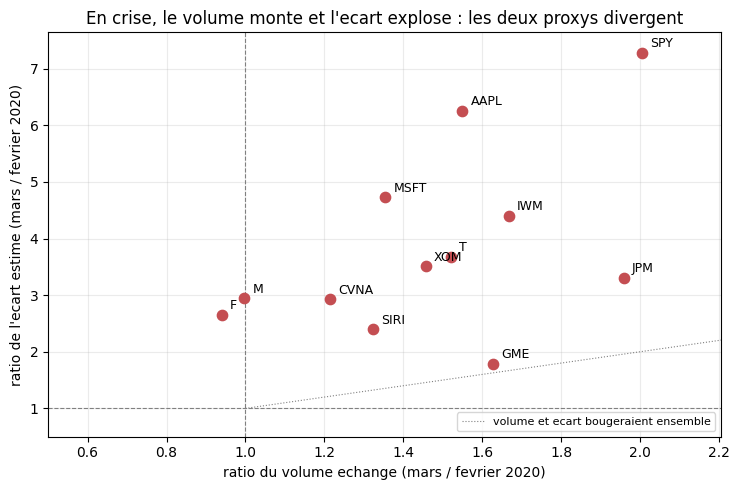

In [6]:
def metriques_fenetre(panneau_local, debut, fin):
    lignes = {}
    for t in UNIVERS:
        complet = panneau_local[("Close", t)].dropna()
        if len(complet) < 5:
            continue
        h = panneau_local[("High", t)].reindex(complet.index)
        l = panneau_local[("Low", t)].reindex(complet.index)
        v = panneau_local[("Volume", t)].reindex(complet.index)
        r = complet.pct_change()
        # L'estimateur a besoin d'une fenetre glissante de 21 seances : on le calcule sur le
        # panneau ENTIER puis on echantillonne la periode. Le calculer sur fevrier seul (19
        # seances) rendrait NaN -- la fenetre n'y tient pas, et le ratio serait indefini.
        ecart = spread_corwin_schultz(h, l).loc[debut:fin]
        lignes[t] = {
            "adv_musd": float((complet.loc[debut:fin] * v.loc[debut:fin]).mean() / 1e6),
            "ecart_cs_bp": float(ecart.median() * 1e4),
            "vol_jour_bp": float(r.loc[debut:fin].std() * 1e4),
        }
    return pd.DataFrame(lignes).T


panneau_2020 = yf.download(UNIVERS, start="2020-01-02", end="2020-07-01",
                           auto_adjust=False, progress=False, threads=True)
fevrier = metriques_fenetre(panneau_2020, "2020-02-01", "2020-02-29")
mars = metriques_fenetre(panneau_2020, "2020-03-01", "2020-03-31")
commun = fevrier.index.intersection(mars.index)

stress = pd.DataFrame(index=commun)
stress["adv_fev_musd"] = fevrier.loc[commun, "adv_musd"]
stress["ratio_adv"] = mars.loc[commun, "adv_musd"] / fevrier.loc[commun, "adv_musd"]
stress["ecart_fev_bp"] = fevrier.loc[commun, "ecart_cs_bp"]
stress["ratio_ecart"] = mars.loc[commun, "ecart_cs_bp"] / fevrier.loc[commun, "ecart_cs_bp"]

# Meme calibrage que la partie 4 : ratio a l'ancre du titre le plus liquide de l'univers.
ancre = proxys["ecart_cs_bp"].min()
demi_fev = fevrier.loc[commun, "ecart_cs_bp"] / ancre * ANCRE_DEMI_ECART_BP
demi_mars = mars.loc[commun, "ecart_cs_bp"] / ancre * ANCRE_DEMI_ECART_BP
stress["capacite_fev_musd"] = participation_max(demi_fev, fevrier.loc[commun, "vol_jour_bp"]) * fevrier.loc[commun, "adv_musd"]
stress["capacite_mars_musd"] = participation_max(demi_mars, mars.loc[commun, "vol_jour_bp"]) * mars.loc[commun, "adv_musd"]
stress["ratio_capacite"] = stress["capacite_mars_musd"] / stress["capacite_fev_musd"]

print("=== stress COVID reel : fevrier -> mars 2020 (memes titres, meme formule) ===")
print(stress.round(3).to_string())
print(f"\nmediane  ratio ADV      : {stress['ratio_adv'].median():.2f}")
print(f"mediane  ratio ecart    : {stress['ratio_ecart'].median():.2f}")
print(f"mediane  ratio capacite : {stress['ratio_capacite'].median():.3f}")
n_adv_hausse = int((stress["ratio_adv"] > 1).sum())
n_capacite_baisse = int((stress["ratio_capacite"] < 1).sum())
print(f"titres dont l'ADV a augmente : {n_adv_hausse} / {len(stress)}")
print(f"titres dont la capacite a baisse : {n_capacite_baisse} / {len(stress)}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.axhline(1, color="gray", lw=0.8, ls="--")
ax.axvline(1, color="gray", lw=0.8, ls="--")
ax.scatter(stress["ratio_adv"], stress["ratio_ecart"], s=55, color="#c44e52", zorder=3)
for t in stress.index:
    ax.annotate(t, (stress["ratio_adv"][t], stress["ratio_ecart"][t]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
limite = max(2.0, float(stress["ratio_ecart"].max()) * 1.05)
ax.plot([1, limite], [1, limite], color="gray", lw=0.8, ls=":", label="volume et ecart bougeraient ensemble")
ax.set_xlim(0.5, float(stress["ratio_adv"].max()) * 1.1)
ax.set_ylim(0.5, limite)
ax.set_xlabel("ratio du volume echange (mars / fevrier 2020)")
ax.set_ylabel("ratio de l'ecart estime (mars / fevrier 2020)")
ax.set_title("En crise, le volume monte et l'ecart explose : les deux proxys divergent")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Lecture du stress

Le résultat mesuré est **contre-intuitif et c'est le cœur du notebook** : sur cette fenêtre, le volume échangé a majoritairement **augmenté** (voir le premier ratio médian) tandis que l'écart estimé a **triplé** (second ratio médian). Autrement dit, la crise a **augmenté** l'indicateur que la plupart des filtres d'univers utilisent (le dollar volume) **et dégradé** celui qui détermine le coût réel (l'écart, donc le coût de traversée).

Trois conséquences, toutes lisibles dans la sortie :

1. **Un filtre d'univers fondé sur l'ADV ne voit pas venir le stress** : il aurait même relâché le filtre au pire moment. C'est un argument mesuré, pas rhétorique, pour filtrer sur l'écart ou sur l'Amihud plutôt que sur le seul volume ;
2. la **capacité se contracte d'un ordre de grandeur** : la médiane des ratios de capacité vaut 0,1, c'est-à-dire des notionnels divisés par dix — alors que dix titres sur douze voyaient leur volume augmenter. Le budget de coût est mangé par le demi-écart et par la volatilité journalière, les deux termes qui ont explosé ;
3. **la contraction est uniforme** — douze titres sur douze en baisse — donc ce n'est pas un accident de composition d'univers mais un régime : un fonds qui aurait calibré sa taille sur la capacité mesurée en février aurait été environ dix fois trop gros en mars.

La limite de l'exercice : février et mars 2020 ne sont pas des régimes « typiques », et un seul épisode ne fait pas une loi. L'exercice 3 rejoue ce même calcul sur un titre et pour votre propre budget.

## 7. Référence QuantConnect Cloud : ce que le moteur modélise à notre place

Tout ce qui précède a été reconstruit à la main, avec des données gratuites. Dans l'IDE QuantConnect, ces trois briques existent déjà et s'activent en quelques lignes :

| Besoin couvert ici | Équivalent QuantConnect | Ce qu'il faut savoir |
|---|---|---|
| Demi-écart | `SetSlippageModel(VolumeShareSlippageModel(...))` | le slippage est facturé **par fill**, en fonction de la part du volume de la barre |
| Filtre d'univers par liquidité | `AddUniverse(CoarseFundamentalUniverseSelectionModel)` + `HasFundamentalData` | le champ `DollarVolume` de `CoarseFundamental` est l'ADV du jour |
| Impact de la taille | `SetLeverage`, `SetHoldings`, `AlgorithmSettings` | QC **ne modélise pas** l'impact de marché : le modèle de slippage reste proportionnel au volume de la barre |
| Coût total du brut | `TotalFees`, `PortfolioStatistics` | les frais sont comptés ; l'impact ne l'est pas |

La cellule suivante contient le code prêt à copier dans `main.py` — elle est **donnée pour référence** et n'est pas exécutée : elle n'a de sens que dans l'IDE Cloud, où `AlgorithmImports` existe.

In [7]:
# [REFERENCE QC] Code a copier dans main.py QC Lab (non executable ici)
# Filtre d'univers par liquidite + modele de slippage : la partie Cloud du grain #16239.
code_qc_liquidite = """
# 16239-liquidity-execution-14b -- filtre de liquidite d'univers et cout d'execution
# Lane myia-po-2023:CoursIA -- See #16239 (ligne 4 : risque de liquidite et couts d'execution)
from AlgorithmImports import *


class LiquiditeEtCouts(QCAlgorithm):

    def initialize(self):
        self.set_start_date(2022, 1, 3)
        self.set_end_date(2024, 12, 31)
        self.set_cash(1_000_000)
        # Filtre d'univers en dollars echangees : proxy d'ADV cote Cloud.
        self.add_universe(self.coarse_selection)
        self.set_universe_settings(UniverseSettings(resolution=Resolution.DAILY, leverage=1.0))
        # Le slippage Cloud est facture par fill, proportionnellement au volume de la barre.
        self.set_security_initializer(lambda security: security.set_slippage_model(
            VolumeShareSlippageModel(volume_share=0.05, price_impact=0.0)))
        self.set_warm_up(30, Resolution.DAILY)
        self._derniere_rebalance = None

    def coarse_selection(self, coarse):
        # Top 50 par dollar volume, prix > 5 $ : plancher de liquidite explicite.
        eligibles = [c for c in coarse if c.has_fundamental_data and c.price > 5]
        return [c.symbol for c in sorted(eligibles, key=lambda c: c.dollar_volume, reverse=True)[:50]]

    def on_data(self, slice):
        if self.is_warming_up or not self.universe_manager.active_securities.count:
            return
        if self._derniere_rebalance is not None and (self.time - self._derniere_rebalance).days < 21:
            return
        self._derniere_rebalance = self.time
        # Equipondere, sans levier : le sujet du notebook est le cout, pas l'alpha.
        actifs = [s for s in self.universe_manager.active_securities.keys if self.securities[s].price > 0]
        if actifs:
            self.set_holdings([PortfolioTarget(s, 1.0 / len(actifs)) for s in actifs], liquidate_existing_holdings=True)

    def on_end_of_algorithm(self):
        # A reporter dans le body de PR : le brut est lisible, le cout d'impact ne l'est pas.
        stats = self.portfolio_statistics
        self.log(f"TotalFees={self.total_portfolio_fees:.2f} | "
                 f"Sharpe={stats.sharpe_ratio:.3f} | MaxDD={stats.max_drawdown:.2%}")
"""

### Ce que la référence Cloud ne remplace pas

Il faut être précis sur la frontière, car elle décide de la validité des conclusions :

- **QC modélise le demi-écart** (via le modèle de slippage) mais **pas l'impact de marché** : `VolumeShareSlippageModel` facture une part du volume de la barre, ce qui est une *forme* de coût de taille, mais aucune des lois d'impact publiées (racine, linéaire) n'y est représentée. La capacité calculée en partie 5 doit donc être reportée **à la main** dans un backtest Cloud, exactement comme ici ;
- **le filtre d'univers Cloud lit `DollarVolume` du jour**, c'est-à-dire précisément le proxy dont la partie 6 a montré qu'il **monte** en crise. Un filtre Cloud naïf ne protège donc pas du risque de liquidité de crise — le notebook le mesure et le dit ;
- **l'exécution Cloud reste une simulation** : les fills sont modélisés, pas observés. C'est la même limite que la nôtre, avec un moteur mieux testé.

Autrement dit, la référence Cloud est un **complément d'ingénierie**, pas une validation des chiffres ci-dessus : les deux mesurent des choses différentes, et c'est la comparaison des deux qui est instructive.

## 8. Exercices

Trois exercices, tous exécutables localement avec les données déjà téléchargées. Ils portent sur ce que le notebook vient de mesurer, pas sur de la syntaxe.

### Exercice 1 — Un cinquième proxy : les jours sans rendement, puis Roll

Le proxy des *jours sans rendement* (Lesmond) est dégénéré sur cet univers (part de l'ordre du pour cent). Mesurez-le proprement, puis ajoutez un second proxy : l'**écart de Roll** (1984), estimé depuis l'auto-covariance des rendements `spread = 2 · √(−cov(r_t, r_{t−1}))` lorsque cette covariance est négative.

- **Étape 1** : tracez la part des séances à rendement nul par titre (déjà calculée dans `proxys`), triée.
- **Étape 2** : calculez `roll_bp` par titre, en ne retenant que les covariances négatives (sinon `NaN`).
- **Étape 3** : comparez le classement obtenu à celui de l'Amihud (Spearman). Le proxy « jours sans rendement » discrimine-t-il cet univers ? Que dit un proxy à `0 %` partout de la granularité des données ?

*Indice* : `rendements` a été réutilisé par le portefeuille ; pour un calcul par titre, repartez de `prix[t].pct_change().dropna()`.

In [8]:
# Exercice 1 -- stub (a completer par l'etudiant)
# Etape 1 : part des seances a rendement nul (colonne deja presente dans proxys)
# Etape 2 : ecart de Roll = 2 * sqrt(-cov(r_t, r_t-1)) sur les seules covariances negatives
# Etape 3 : correlation de rang avec l'Amihud -- le proxy discrimine-t-il cet univers ?

roll_bp = None  # TODO etudiant : pd.Series indexee par titre, en points de base
comparaison_rangs = None  # TODO etudiant : tableau de rangs Amihud / Roll / jours sans rendement

if roll_bp is None:
    print("Exercice a completer : ajouter l'ecart de Roll et comparer les classements")

Exercice a completer : ajouter l'ecart de Roll et comparer les classements


### Exercice 2 — La taille ne fait pas le coût : elle en fait la racine

Reprenez le portefeuille de la partie 5 et faites varier `AUM_MUSD` sur une grille (10, 50, 200, 1 000, 5 000 M$). Pour chaque taille, relevez le drag annuel en bp et le titre contraignant.

- **Étape 1** : factorisez la boucle de la partie 5 dans une fonction `simule(aum)` qui rend `(cagr_net, drag_bp_an, titre_contraignant)`.
- **Étape 2** : tracez le drag annuel contre l'AUM, en échelle log-log.
- **Étape 3** : quelle pente observez-vous ? La loi racine prédit une pente proche de 0,5 **tant que l'impact domine** ; une pente proche de 0 signifie que le demi-écart domine encore. À partir de quelle taille l'impact domine-t-il ?

*Anti-piège* : à très grande taille, la participation dépasse 1 (on échangerait plus que le volume du jour) — la formule reste calculable mais sort de son domaine de validité. Signalez ces points au lieu de les tracer comme les autres.

In [9]:
# Exercice 2 -- stub (a completer par l'etudiant)
# Etape 1 : refactoriser la boucle de la partie 5 en fonction simule(aum) -> (cagr_net, drag_bp_an, contraignant)
# Etape 2 : tracer drag_bp_an contre aum en log-log
# Etape 3 : mesurer la pente ; verifier si la participation reste < 1 (domaine de validite)

drag_par_taille = None  # TODO etudiant : DataFrame indexe par AUM

if drag_par_taille is None:
    print("Exercice a completer : mesurer le drag annuel pour une grille de tailles de fonds")

Exercice a completer : mesurer le drag annuel pour une grille de tailles de fonds


### Exercice 3 — Stress d'un titre : le budget de coût en crise

Choisissez le titre contraignant identifié en partie 5. Appliquez-lui la détérioration **mesurée** en mars 2020 (son `ratio_ecart` et son `ratio_adv` réels de la partie 6) à ses paramètres d'aujourd'hui, et recalculez :

- **Étape 1** : nouveau demi-écart et nouvel ADV après stress.
- **Étape 2** : nouvelle capacité à budget inchangé (20 bp) ; exprimez-la en **facteur** de la capacité actuelle.
- **Étape 3** : participation maximale qui tient le budget sous stress. Traduite en jours de liquidité (`participation_max × ADV / montant_ordre`), combien de séances faudrait-il pour sortir la position d'un fonds de 200 M$ ?

*Attendu* : le facteur de capacité doit être nettement inférieur à 1, et le nombre de séances doit **exploser** — c'est le même résultat que la médiane de la partie 6, appliqué à un titre unique.

In [10]:
# Exercice 3 -- stub (a completer par l'etudiant)
# Etape 1 : appliquer le ratio_ecart et le ratio_adv COVID du titre contraignant
# Etape 2 : recalculer la capacite a budget 20 bp et l'exprimer en facteur
# Etape 3 : en deduire la participation max sous stress et les seances necessaires pour 200 M$

capacite_stressee_musd = None  # TODO etudiant : capacite du titre contraignant sous stress COVID
seances_pour_sortir = None     # TODO etudiant : jours de liquidite pour 200 M$ sous stress

if capacite_stressee_musd is None:
    print("Exercice a completer : stresser le titre contraignant et mesurer la perte de capacite")

Exercice a completer : stresser le titre contraignant et mesurer la perte de capacite


### Attendus et anti-pièges

**Exercice 1.** *Attendu* : les jours sans rendement classent très mal cet univers (parts faibles, plusieurs titres à zéro) — le proxy ne discrimine qu'à partir d'échantillonnages plus fins (intraday) ou d'univers beaucoup plus étroits. L'écart de Roll, lui, donne un classement **partiellement** corrélé à l'Amihud, avec des divergences informatives. *Anti-piège* : compter un rendement nul **après arrondi** (les prix sont cotés au centime — un `r == 0` strict est rare sur un titre liquide, mais `round(r, 4) == 0` ne l'est pas : dites lequel vous utilisez). Second anti-piège : Roll n'existe que si la covariance est **négative** ; renvoyer `0` au lieu de `NaN` quand elle est positive fabrique une corrélation artificielle.

**Exercice 2.** *Attendu* : le drag augmente avec la taille mais **moins vite que proportionnellement** dans le régime d'impact (pente log-log ≈ 0,5), et plus vite que proportionnellement nulle part — sauf si l'on oublie que la participation sort du domaine de validité (participation > 1). Le titre contraignant doit rester le même sur toute la grille tant que les coûts croissent de façon monotone en taille. *Anti-piège* : comparer des drags calculés avec des **AUM différents dans la même courbe** de portefeuille (le drag dépend du chemin : une valeur nette plus faible échange moins). Recalculer la valeur du portefeuille à chaque taille, comme en partie 5 — pas appliquer un coût constant.

**Exercice 3.** *Attendu* : le facteur de capacité est nettement inférieur à 1 et les jours de liquidité pour 200 M$ passent de quelques séances à plusieurs dizaines. C'est la traduction en jours de ce que la partie 6 disait en dollars. *Anti-piège* : appliquer le ratio d'écart à l'**ADV** (les deux composantes sont mesurées séparément, elles ne se multiplient pas) ; et ne pas oublier que la volatilité journalière du titre a elle aussi augmenté en mars 2020 — l'ignorer **sous-estime** la perte de capacité.

## 9. Limites et honnêteté du socle

- **Le niveau absolu des écarts est posé, pas mesuré.** L'ancre de 0,5 bp pour le titre le plus liquide est une hypothèse de calibrage ; seuls les *ratios entre titres* sont mesurés par l'estimateur de Corwin-Schultz. Changer l'ancre décale toutes les capacités dans le même rapport sans changer aucun classement — c'est la raison pour laquelle tous les résultats de ce notebook s'expriment en comparaisons et en facteurs.
- **Données quotidiennes uniquement.** Aucune information de carnet : ni profondeur, ni VWAP intraday, ni granularité des fills. La participation est estimée sur le volume du jour entier, ce qui **surestime** la liquidité disponible pendant la fenêtre où l'on veut réellement échanger.
- **Univers choisi ex post.** Les douze titres ont été retenus en 2026 pour couvrir la gamme de liquidité, et tous ont survécu à la période. C'est un biais de survie favorable : les titres disparus sont précisément ceux dont la liquidité s'est effondrée.
- **Un épisode de stress, une fenêtre.** Février contre mars 2020 est un cas réel mais unique ; la contraction mesurée n'est pas une loi, c'est une observation datée. Les exercices invitent à rejouer le calcul plutôt qu'à généraliser.
- **Le portefeuille de la partie 5 est un support, pas une stratégie.** Équipondéré, rebalancé mensuellement, sans signal alpha : il sert à mesurer un *coût*, et son CAGR n'a aucune valeur prédictive.
- **Ce que le notebook ne fait pas, et qui est nommé** : aucun run de backtest QuantConnect n'est exécuté ici. La partie 7 fournit le code Cloud et dit précisément ce qu'il modélise et ce qu'il ne modélise pas (l'impact de marché n'y est pas représenté). Le socle mesuré localement est le livrable ; le Cloud est le complément d'ingénierie, pas la validation des chiffres.

## Conclusion

**Ce que couvre ce livrable** (mapping acceptance #16239, ligne 4 de la matrice : « Mesures de liquidité et incidence sur exécution / sizing à rendre explicites ») :

- **Quatre proxys mesurés, pas un** : ADV en dollars, Amihud, écart estimé de Corwin-Schultz et jours sans rendement, avec leur matrice de corrélation — un proxy unique n'est jamais une mesure de liquidité ;
- **Un indicateur falsifiable distinct du risque de marché** : le test de la partie 3 compte les titres hors diagonale entre illiquidité et volatilité, et les nomme ;
- **Une traduction en dollars** : participation, coût, capacité par titre, puis un portefeuille brut contre net — l'hypothèse « exécution gratuite » de `QC-Py-14` chiffrée ;
- **Un stress sur un épisode réel** : février contre mars 2020, où le volume monte et l'écart explose — la démonstration que le filtre d'univers le plus répandu (le dollar volume) est aveugle au moment où il faudrait voir ;
- **Limites écrites** : ancre de calibrage posée, données quotidiennes, univers survivant, un seul épisode, et la frontière explicite avec ce que QuantConnect modélise ou non.

**Fil de la série.** `QC-Py-14` construit le portefeuille, `QC-Py-15` optimise ses paramètres : tous deux raisonnent en rendement brut. **14b est le péage** — il ne cherche pas d'alpha, il mesure ce que coûte la croyance que le capital est une abstraction. Le réflexe à emporter n'est pas une formule mais une question : *à quelle participation mon résultat a-t-il été calculé ?*